In [2]:
import sys
print(sys.executable)

c:\Users\Windows10\anaconda3\python.exe


In [3]:
!{sys.executable} -m pip install prophet

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [5]:
df= pd.read_csv("../data/processed/final_df.csv")
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown1_missing,MarkDown2_missing,MarkDown3_missing,MarkDown4_missing,MarkDown5_missing,year,month,week,weekday,is_weekend
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,...,1,1,1,1,1,2010,2,5,4,False
1,29,5,2010-02-05,15552.08,False,24.36,2.788,NaN,NaN,NaN,...,1,1,1,1,1,2010,2,5,4,False
2,29,6,2010-02-05,3200.22,False,24.36,2.788,NaN,NaN,NaN,...,1,1,1,1,1,2010,2,5,4,False
3,29,7,2010-02-05,10820.05,False,24.36,2.788,NaN,NaN,NaN,...,1,1,1,1,1,2010,2,5,4,False
4,29,8,2010-02-05,20055.64,False,24.36,2.788,NaN,NaN,NaN,...,1,1,1,1,1,2010,2,5,4,False


In [6]:
print(df['Date'].head())
print(df['Date'].dtype)

0    2010-02-05
1    2010-02-05
2    2010-02-05
3    2010-02-05
4    2010-02-05
Name: Date, dtype: object
object


In [7]:
print(df['Date'].min())
print(df['Date'].max())

2010-02-05
2012-10-26


**Why data aggregation in the way below**

I aggregated the dataset by Date and summed Weekly_Sales in order to transform the original multi-store dataset into a single consistent time series.

The original data contained multiple records for the same date (one per store), which means that each timestamp had several values associated with it.

This structure is not suitable for time series forecasting models like Prophet.

No aggregation -> dataset contains duplicate timestamps and an extremely large number of rows -> overflow error.

In [8]:
df_aggr= df.groupby('Date')['Weekly_Sales'].sum().reset_index()

df_aggr.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [9]:
df_aggr['Date'] = pd.to_datetime(df_aggr['Date'])

In [10]:
# Check the temporal structure and frequency of the aggregated time series and the time range
print(df_aggr['Date'].min())
print(df_aggr['Date'].max())

print(df_aggr['Date'].nunique())

# Time interval between consecutive observations
print(
    df_aggr['Date']
    .sort_values()
    .diff()
    .value_counts()
)

2010-02-05 00:00:00
2012-10-26 00:00:00
143
Date
7 days    142
Name: count, dtype: int64


In [33]:
df_aggr.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


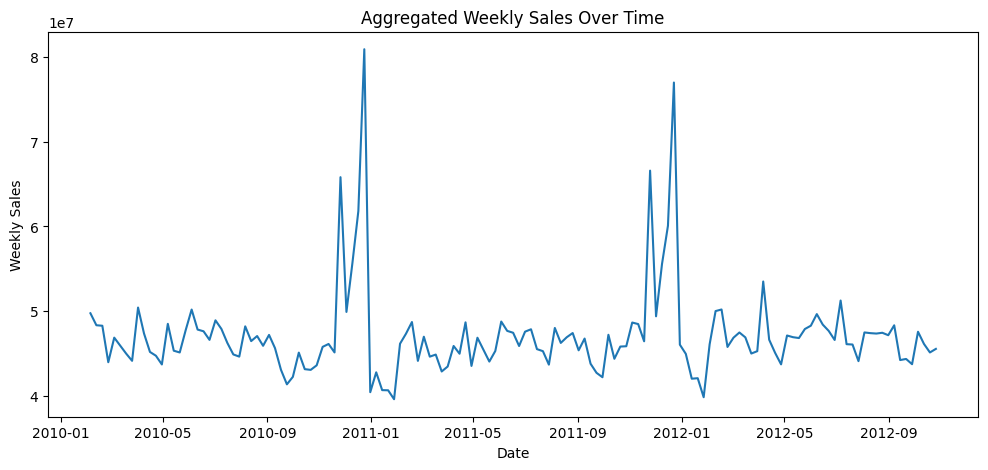

In [34]:
# Plot the aggregated weekly sales over time

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_aggr['Date'], df_aggr['Weekly_Sales'])

plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Aggregated Weekly Sales Over Time')

plt.show()

In [35]:
df_aggr['WoW_Change'] = df_aggr['Weekly_Sales'].pct_change()

df_aggr[['Date', 'Weekly_Sales', 'WoW_Change']].head()

,Date,Weekly_Sales,WoW_Change
0,2010-02-05,49750740.50,NaN
1,2010-02-12,48336677.63,-0.028423
2,2010-02-19,48276993.78,-0.001235
3,2010-02-26,43968571.13,-0.089244
4,2010-03-05,46871470.30,0.066022


In [11]:
# Rename columns
df_prophet= df_aggr.rename(
    columns={
        'Date': 'ds',
        'Weekly_Sales': 'y'}) # prophet always want 'ds' and 'y'

In [12]:
# Let's convert Date -> date type
df_prophet['ds']= pd.to_datetime(df_prophet['ds'], errors='coerce') # errors=coerce -> erros -> Nat

In [13]:
# Check the data type
df_prophet['ds'].dtype

dtype('<M8[ns]')

In [14]:
df_prophet = df_prophet.dropna() # to be more sure

In [15]:
df_prophet= df_prophet.sort_values('ds')

In [16]:
df_prophet.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


## Prophet Model

Temporal split -> train & test set

In [17]:
split= int(len(df_prophet)*0.8)
train= df_prophet.iloc[:split] # 'past'
test= df_prophet.iloc[split:] # fake 'features'

In [18]:
print(len(train))
print("-"*10)
print(len(test))

114
----------
29


In [19]:
train.columns

Index(['ds', 'y'], dtype='object')

In [20]:
# Fit the model
model_base= Prophet()
model_base.fit(train)

15:56:12 - cmdstanpy - INFO - Chain [1] start processing
15:56:15 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
# Create the 'future' (test set period)
future= model_base.make_future_dataframe(periods=len(test), freq='W')
# Forecast
forecast= model_base.predict(future)

In [22]:
# Let's see the results (yhat -> forecast, yhat_lower & yhat_upper -> lower / upper limit
forecast[['ds','yhat','yhat_lower','yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2010-02-05,4.754156e+07,4.308276e+07,5.252863e+07
1,2010-02-12,4.817145e+07,4.300856e+07,5.295315e+07
2,2010-02-19,4.680127e+07,4.183212e+07,5.156060e+07
3,2010-02-26,4.571452e+07,4.090716e+07,5.070026e+07
4,2010-03-05,4.552954e+07,4.056424e+07,5.025504e+07


Let's **visualize** it

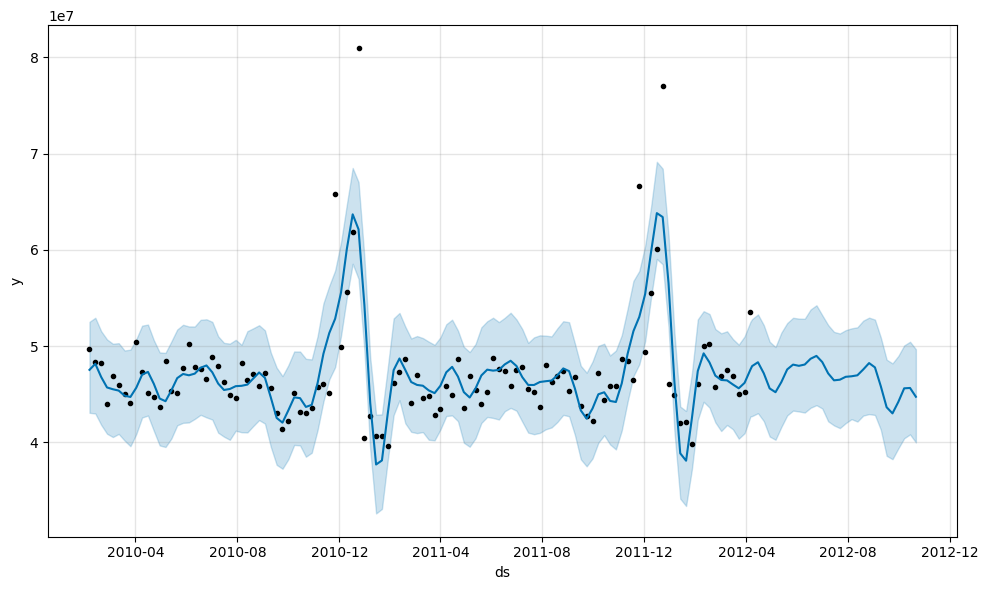

In [23]:
fig1= model_base.plot(forecast)

Q4 spikes predicted

## **Seasonality/Trend** (below)

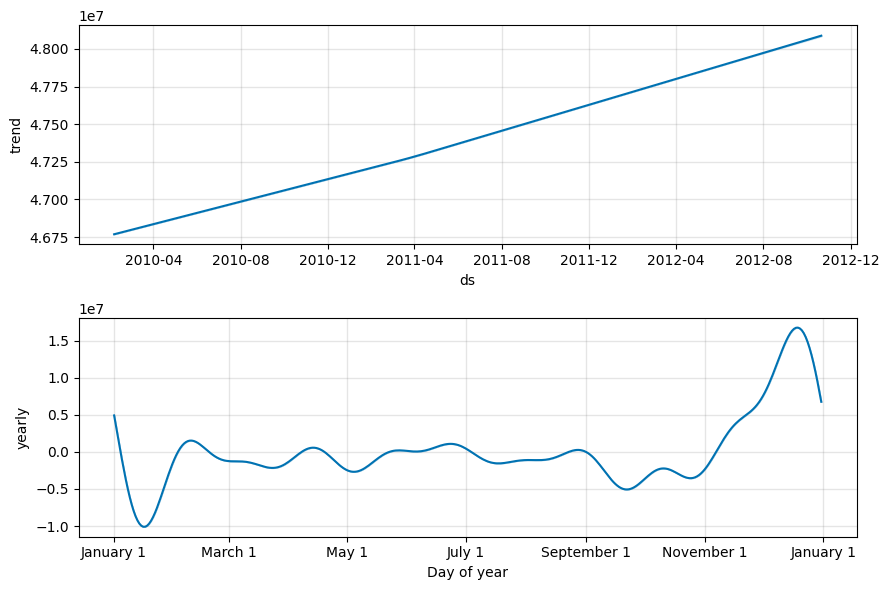

In [24]:
fig2= model_base.plot_components(forecast)

Same spikes

## Comparison (real values vs forecast)

**Note**:
- a key issue was that forecasted dates generated by Prophet did not perfectly match the test dataset dates, making a direct merge impossible.
- to solve this -> aligned predictions and actual values by position (index) instead of date .

In [25]:
# Only forecast aligned with test (real values)
forecast_test = forecast.iloc[-len(test):].copy()
test = test.copy()

In [26]:
forecast_test = forecast_test.reset_index(drop=True)
test = test.reset_index(drop=True)

In [27]:
comparison= pd.DataFrame({
        'ds': test['ds'],
        'y': test['y'],
        'yhat': forecast_test['yhat']
})

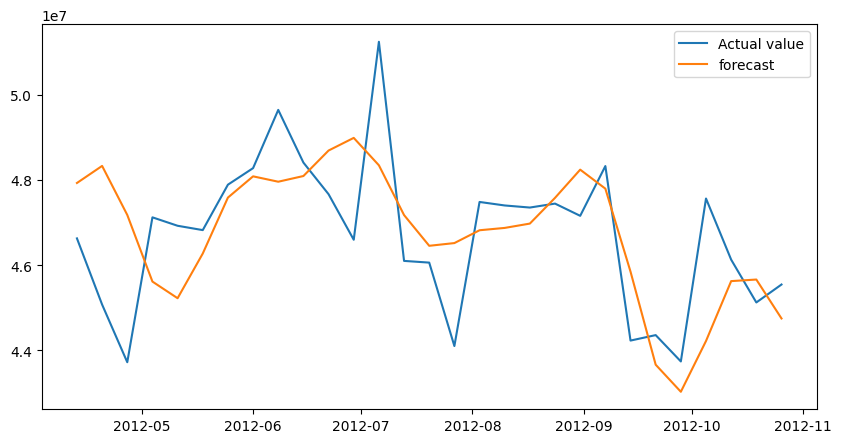

In [28]:
# Visualize it
plt.figure(figsize=(10,5))
plt.plot(comparison['ds'],comparison['y'],label='Actual value')
plt.plot(comparison['ds'],comparison['yhat'],label='forecast')
plt.legend()
plt.show()

## Evaluation

In [29]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(comparison['y'], comparison['yhat'])
print(mae)

1243555.5901629017


Model error-> ~1.24 mln sales

**Let'use MAPE -> % error**

In [30]:
from sklearn.metrics import mean_absolute_percentage_error

mape= mean_absolute_percentage_error(comparison['y'], comparison['yhat'])
print(mape)

0.026777485794710284


**Result**: the model achieved a Mean Absolute Percentage Error (MAPE) of 2.6% -> very high forecasting accuracy

## Save the model

In [31]:
import joblib

In [32]:
joblib.dump(model_base,'forecast_model.pkl')

['forecast_model.pkl']